# CMPE 252 Project 2: English-to-German Neural Machine Translation

## Group Members:
Daniel Chiu  |
Benjamin Kwon

## Our Project

The goal of this project is to build and evaluate a neural machine translation model for English-to-German translation using a WMT dataset. We will be using the Transformer pretrained model 'Helsinki-NLP/opus-mt-en-de'. This model uses the MarianMT Transformer encoder-decoder architecture.

The baseline is the pretrained Helsinki model evaluated on the development set. The improvement step fine-tunes the same model on a WMT training subset, then compares development loss and SacreBLEU scores across experiments.

### Pretrained Model:

Helsinki-NLP/opus-mt-en-de

### Dataset

- Training data
    - Europarl v10
    - News Commentary v18.1
- Development/Validaiton set
    - newstest_deen-2019
- Test set
    - newstest_deen-2020

### Metric
The evaluation metric is SacreBLEU which utilizies a score range from 0-100.

In [1]:
# =========================
# Global Configuration
# =========================

from pathlib import Path
import math

# -------------------------
# Reproducibility
# -------------------------

RANDOM_SEED = 42

# -------------------------
# Run settings
# -------------------------

RUN_ID = "exp14_subset50000_lr8e-8_epoch3_lsf0.05" # Edit the name of the experiment before running it

# -------------------------
# Model settings
# -------------------------

MODEL_NAME = "Helsinki-NLP/opus-mt-en-de"

# -------------------------
# Local dataset paths
# -------------------------

DATA_DIR = Path("data/deu-eng")

TRAIN_SOURCE_PATH = DATA_DIR / "train.eng"
TRAIN_TARGET_PATH = DATA_DIR / "train.deu"

DEV_SOURCE_PATH = DATA_DIR / "dev.eng"
DEV_TARGET_PATH = DATA_DIR / "dev.deu"

TEST_SOURCE_PATH = DATA_DIR / "test.eng"
TEST_TARGET_PATH = DATA_DIR / "test.deu"

SOURCE_LANG = "en"
TARGET_LANG = "de"

TRAIN_SUBSET_SIZE = 50_000

# -------------------------
# Tokenization settings
# -------------------------

MAX_SOURCE_LENGTH = 128
MAX_TARGET_LENGTH = 128

# -------------------------
# Training hyperparameters
# -------------------------

PER_DEVICE_TRAIN_BATCH_SIZE = 16
PER_DEVICE_EVAL_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1

LEARNING_RATE = 8e-8
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06 # Change this to affect the WARMUP_STEPS

# Do not change the following:
EFFECTIVE_BATCH_SIZE = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
STEPS_PER_EPOCH = math.ceil(TRAIN_SUBSET_SIZE / EFFECTIVE_BATCH_SIZE)
TOTAL_TRAINING_STEPS = STEPS_PER_EPOCH * NUM_EPOCHS
WARMUP_STEPS = math.ceil(TOTAL_TRAINING_STEPS * WARMUP_RATIO)
# You can change any hyperparameters after this line

LABEL_SMOOTHING_FACTOR = 0.05

FP16 = True
GROUP_BY_LENGTH = True

# -------------------------
# Generation / inference settings
# -------------------------

NUM_BEAMS = 4
MAX_NEW_TOKENS = 128
LENGTH_PENALTY = 1.0
EARLY_STOPPING = True

In [2]:
# -------------------------
# Output directories
# -------------------------

OUTPUT_DIR = Path("outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
TRANSLATIONS_DIR = OUTPUT_DIR / "translations"

BASELINE_RUN_ID = "baseline_helsinki"

BASELINE_METRICS_DIR = METRICS_DIR / BASELINE_RUN_ID
EXPERIMENT_METRICS_DIR = METRICS_DIR / RUN_ID

EXPERIMENT_FIGURES_DIR = FIGURES_DIR / RUN_ID

EXPERIMENT_TRANSLATIONS_DIR = TRANSLATIONS_DIR / RUN_ID

BASELINE_CHECKPOINT_DIR = CHECKPOINT_DIR / "baseline_helsinki"
EXPERIMENT_CHECKPOINT_DIR = CHECKPOINT_DIR / RUN_ID
FINAL_MODEL_DIR = CHECKPOINT_DIR / "final_selected_model"

for directory in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    BASELINE_METRICS_DIR,
    EXPERIMENT_METRICS_DIR,
    FIGURES_DIR,
    EXPERIMENT_FIGURES_DIR,
    TRANSLATIONS_DIR,
    EXPERIMENT_TRANSLATIONS_DIR,
    BASELINE_CHECKPOINT_DIR,
    EXPERIMENT_CHECKPOINT_DIR,
    FINAL_MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Run ID:", RUN_ID)
print("Data directory:", DATA_DIR)
print("Baseline metrics directory:", BASELINE_METRICS_DIR)
print("Experiment metrics directory:", EXPERIMENT_METRICS_DIR)
print("Output directory:", OUTPUT_DIR.resolve())

Model: Helsinki-NLP/opus-mt-en-de
Run ID: exp13_subset50000_lr8e-8_epoch3_lsf0.1
Data directory: data\deu-eng
Baseline metrics directory: outputs\metrics\baseline_helsinki
Experiment metrics directory: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1
Output directory: M:\Git Repository\NMT-HF-Transformers-Helsinki-opus-en-de-wmt\outputs


In [3]:
# =========================
# Imports and Installs
# =========================

import os
import json
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import Dataset, DatasetDict

import evaluate

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    set_seed,
)

# Install:
# sentencepiece
# sacrebleu
# transformers[torch]

warnings.filterwarnings("ignore")

print("Imports completed.")

Imports completed.


In [4]:
# =========================
# Reproducibility
# =========================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
set_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [5]:
# =========================
# Device Check
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("CUDA is not available. Training will run on CPU and may be slow.")

Device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
CUDA version: 13.0


In [6]:
# =========================
# Save Configuration Snapshot
# =========================

config = {
    "random_seed": RANDOM_SEED,
    "run_id": RUN_ID,
    "model_name": MODEL_NAME,
    "source_lang": SOURCE_LANG,
    "target_lang": TARGET_LANG,
    "train_source_path": str(TRAIN_SOURCE_PATH),
    "train_target_path": str(TRAIN_TARGET_PATH),
    "dev_source_path": str(DEV_SOURCE_PATH),
    "dev_target_path": str(DEV_TARGET_PATH),
    "test_source_path": str(TEST_SOURCE_PATH),
    "test_target_path": str(TEST_TARGET_PATH),
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "max_source_length": MAX_SOURCE_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "warmup_steps": WARMUP_STEPS,
    "label_smoothing_factor": LABEL_SMOOTHING_FACTOR,
    "fp16": FP16,
    "group_by_length": GROUP_BY_LENGTH,
    "num_beams": NUM_BEAMS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "length_penalty": LENGTH_PENALTY,
    "early_stopping": EARLY_STOPPING,
    "baseline_checkpoint_dir": str(BASELINE_CHECKPOINT_DIR),
    "experiment_checkpoint_dir": str(EXPERIMENT_CHECKPOINT_DIR),
    "final_model_dir": str(FINAL_MODEL_DIR),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

config_path = EXPERIMENT_METRICS_DIR / "_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved configuration to:", config_path)

Saved configuration to: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1\_config.json


## Dataset Loading

In [7]:
# =========================
# Dataset Loading Helpers
# =========================

def read_text_file(path):
    """
    Read a plain text file where each line is one sentence.
    Empty lines are preserved so that source and target files keep the same line alignment.
    Empty source-target pairs can be filtered later after both files are loaded together.
    """
    with open(path, "r", encoding="utf-8") as f:
        lines = [line.rstrip("\n") for line in f.readlines()]
    return lines


def build_parallel_dataset(source_path, target_path, split_name):
    """
    Build a Hugging Face Dataset from parallel source and target text files.
    """
    sources = read_text_file(source_path)
    targets = read_text_file(target_path)
    
    print(f"{split_name} source lines:", len(sources))
    print(f"{split_name} target lines:", len(targets))
    
    if len(sources) != len(targets):
        raise ValueError(
            f"Line count mismatch in {split_name}: "
            f"{source_path} has {len(sources)} lines, "
            f"but {target_path} has {len(targets)} lines."
        )

    pairs = [
        (source.strip(), target.strip())
        for source, target in zip(sources, targets)
        if source.strip() and target.strip()
    ]

    print(f"{split_name} non-empty aligned pairs:", len(pairs))

    clean_sources = [source for source, target in pairs]
    clean_targets = [target for source, target in pairs]
    
    dataset = Dataset.from_dict({
        "source": clean_sources,
        "reference": clean_targets,
    })
    
    return dataset

# =========================
# Load Train / Dev / Test Datasets
# =========================

train_dataset_full = build_parallel_dataset(
    TRAIN_SOURCE_PATH,
    TRAIN_TARGET_PATH,
    split_name="train"
)

dev_dataset = build_parallel_dataset(
    DEV_SOURCE_PATH,
    DEV_TARGET_PATH,
    split_name="dev"
)

test_dataset = build_parallel_dataset(
    TEST_SOURCE_PATH,
    TEST_TARGET_PATH,
    split_name="test"
)

dataset_dict = DatasetDict({
    "train_full": train_dataset_full,
    "dev": dev_dataset,
    "test": test_dataset,
})

dataset_dict

train source lines: 2255270
train target lines: 2255270
train non-empty aligned pairs: 2255270
dev source lines: 2000
dev target lines: 2000
dev non-empty aligned pairs: 2000
test source lines: 785
test target lines: 785
test non-empty aligned pairs: 785


DatasetDict({
    train_full: Dataset({
        features: ['source', 'reference'],
        num_rows: 2255270
    })
    dev: Dataset({
        features: ['source', 'reference'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['source', 'reference'],
        num_rows: 785
    })
})

In [8]:
# =========================
# Create Training Subset
# =========================

if TRAIN_SUBSET_SIZE is not None and TRAIN_SUBSET_SIZE < len(train_dataset_full):
    train_dataset = (
        train_dataset_full
        .shuffle(seed=RANDOM_SEED)
        .select(range(TRAIN_SUBSET_SIZE))
    )
else:
    train_dataset = train_dataset_full

print("Full training examples:", len(train_dataset_full))
print("Training subset examples:", len(train_dataset))
print("Development examples:", len(dev_dataset))
print("Test examples:", len(test_dataset))

Full training examples: 2255270
Training subset examples: 50000
Development examples: 2000
Test examples: 785


In [9]:
# =========================
# Preview Dataset Examples
# =========================

preview_count = 5

for i in range(min(preview_count, len(train_dataset))):
    print("=" * 80)
    print("Example:", i)
    print("Source English:")
    print(train_dataset[i]["source"])
    print()
    print("Reference German:")
    print(train_dataset[i]["reference"])

Example: 0
Source English:
Nobody in Europe should feel isolated and excluded without an opportunity to travel.

Reference German:
In Europa sollte sich niemand isoliert und ausgeschlossen und ohne jegliche Gelegenheit, zu reisen, fühlen.
Example: 1
Source English:
Mr President, Mr Leterme, ladies and gentlemen, with efficiency and focus, with pragmatism and Community spirit, the Union made important advances during the Belgian Presidency, which deserve our admiration and our recognition.

Reference German:
Herr Präsident, Herr Leterme, meine Damen und Herren, die Union hat während des belgischen Ratsvorsitzes mit Effizienz und Konzentration, mit Pragmatismus und Gemeinschaftsgeist wichtige Fortschritte gemacht, die unsere Bewunderung und unsere Anerkennung verdienen.
Example: 2
Source English:
Why are all countries equal, but certain large countries more equal than others?

Reference German:
Weshalb sind alle Länder gleich, einige große Länder aber gleicher als andere?
Example: 3
Sour

In [10]:
# =========================
# Basic Length Statistics
# =========================

def add_length_columns(example):
    example["source_word_count"] = len(example["source"].split())
    example["reference_word_count"] = len(example["reference"].split())
    return example


train_dataset_with_lengths = train_dataset.map(add_length_columns)
dev_dataset_with_lengths = dev_dataset.map(add_length_columns)
test_dataset_with_lengths = test_dataset.map(add_length_columns)

length_summary = pd.DataFrame({
    "split": ["train_subset", "dev", "test"],
    "num_examples": [
        len(train_dataset_with_lengths),
        len(dev_dataset_with_lengths),
        len(test_dataset_with_lengths),
    ],
    "avg_source_words": [
        np.mean(train_dataset_with_lengths["source_word_count"]),
        np.mean(dev_dataset_with_lengths["source_word_count"]),
        np.mean(test_dataset_with_lengths["source_word_count"]),
    ],
    "avg_reference_words": [
        np.mean(train_dataset_with_lengths["reference_word_count"]),
        np.mean(dev_dataset_with_lengths["reference_word_count"]),
        np.mean(test_dataset_with_lengths["reference_word_count"]),
    ],
    "max_source_words": [
        max(train_dataset_with_lengths["source_word_count"]),
        max(dev_dataset_with_lengths["source_word_count"]),
        max(test_dataset_with_lengths["source_word_count"]),
    ],
    "max_reference_words": [
        max(train_dataset_with_lengths["reference_word_count"]),
        max(dev_dataset_with_lengths["reference_word_count"]),
        max(test_dataset_with_lengths["reference_word_count"]),
    ],
})

length_summary

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/785 [00:00<?, ? examples/s]

,split,num_examples,avg_source_words,avg_reference_words,max_source_words,max_reference_words
0,train_subset,50000,24.569760,23.283680,249,190
1,dev,2000,17.193000,15.548500,72,58
2,test,785,43.033121,39.528662,151,134


## Load Model and Tokenizer

In [11]:
# =========================
# Load Model and Tokenizer
# =========================

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME)

model = model.to(device)

print("Loaded tokenizer and model.")
print("Model name:", MODEL_NAME)
print("Device:", device)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loaded tokenizer and model.
Model name: Helsinki-NLP/opus-mt-en-de
Device: cuda


In [12]:
# =========================
# Inspect Model Configuration
# =========================

model_config = model.config

architecture_summary = {
    "model_type": model_config.model_type,
    "architectures": model_config.architectures,
    "vocab_size": model_config.vocab_size,
    "encoder_layers": model_config.encoder_layers,
    "decoder_layers": model_config.decoder_layers,
    "encoder_attention_heads": model_config.encoder_attention_heads,
    "decoder_attention_heads": model_config.decoder_attention_heads,
    "d_model": model_config.d_model,
    "encoder_ffn_dim": model_config.encoder_ffn_dim,
    "decoder_ffn_dim": model_config.decoder_ffn_dim,
    "max_position_embeddings": model_config.max_position_embeddings,
    "pad_token_id": model_config.pad_token_id,
    "eos_token_id": model_config.eos_token_id,
    "decoder_start_token_id": model_config.decoder_start_token_id,
}

architecture_summary_df = pd.DataFrame(
    architecture_summary.items(),
    columns=["Configuration Item", "Value"]
)

architecture_summary_df

,Configuration Item,Value
0,model_type,marian
1,architectures,[MarianMTModel]
2,vocab_size,58101
3,encoder_layers,6
4,decoder_layers,6
5,encoder_attention_heads,8
6,decoder_attention_heads,8
7,d_model,512
8,encoder_ffn_dim,2048
9,decoder_ffn_dim,2048


In [13]:
# =========================
# Save Architecture Summary
# =========================

architecture_summary_path = METRICS_DIR / "baseline_model_architecture_summary.csv"

architecture_summary_df.to_csv(architecture_summary_path, index=False)

print("Saved architecture summary to:", architecture_summary_path)

Saved architecture summary to: outputs\metrics\baseline_model_architecture_summary.csv


In [14]:
# =========================
# Load SacreBLEU Metric
# =========================

sacrebleu = evaluate.load("sacrebleu")

print("Loaded SacreBLEU metric.")

Loaded SacreBLEU metric.


In [15]:
# =========================
# Translation Helper
# =========================

def translate_texts(
    texts,
    model,
    tokenizer,
    batch_size=16,
    max_source_length=128,
    num_beams=4,
    max_new_tokens=128,
    length_penalty=1.0,
    early_stopping=True,
    device=device,
):
    """
    Translate a list of source texts using the given model and tokenizer.
    """
    model.eval()
    predictions = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded_batch = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_source_length,
        ).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                **encoded_batch,
                num_beams=num_beams,
                max_new_tokens=max_new_tokens,
                length_penalty=length_penalty,
                early_stopping=early_stopping,
                max_length=None,
            )

        batch_predictions = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )

        predictions.extend(batch_predictions)

    return predictions

In [16]:
# =========================
# Evaluation Helper
# =========================

def evaluate_translation_sacrebleu(
    dataset,
    model,
    tokenizer,
    batch_size=16,
    max_source_length=128,
    num_beams=4,
    max_new_tokens=128,
    length_penalty=1.0,
    early_stopping=True,
    device=device,
):
    """
    Generate translations for a dataset and compute SacreBLEU.
    
    The dataset must contain:
    - source
    - reference
    """
    sources = dataset["source"]
    references = dataset["reference"]

    predictions = translate_texts(
        texts=sources,
        model=model,
        tokenizer=tokenizer,
        batch_size=batch_size,
        max_source_length=max_source_length,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        length_penalty=length_penalty,
        early_stopping=early_stopping,
        device=device,
    )

    # SacreBLEU expects:
    # predictions: List[str]
    # references: List[List[str]]
    # For one reference per source, wrap references in an outer list.
    sacrebleu_result = sacrebleu.compute(
        predictions=predictions,
        references=[[ref] for ref in references],
    )

    return {
        "sacrebleu": sacrebleu_result["score"],
        "predictions": predictions,
        "references": references,
        "sources": sources,
        "raw_sacrebleu": sacrebleu_result,
    }

## Baseline Dev Evaluation
These codes will be put into Markdown or 'inactive' form after they run and their results are recorded.

# =========================
# Full Baseline Dev Evaluation
# =========================

baseline_dev_result = evaluate_translation_sacrebleu(
    dataset=dev_dataset,
    model=model,
    tokenizer=tokenizer,
    batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    max_source_length=MAX_SOURCE_LENGTH,
    num_beams=NUM_BEAMS,
    max_new_tokens=MAX_NEW_TOKENS,
    length_penalty=LENGTH_PENALTY,
    early_stopping=EARLY_STOPPING,
    device=device,
)

baseline_dev_sacrebleu = baseline_dev_result["sacrebleu"]

print("Baseline Dev SacreBLEU:", baseline_dev_sacrebleu)

# =========================
# Save Baseline Dev Metrics
# =========================

baseline_metrics = {
    "run_id": "baseline_helsinki",
    "model_name": MODEL_NAME,
    "split": "dev",
    "sacrebleu": baseline_dev_sacrebleu,
    "num_examples": len(dev_dataset),
    "num_beams": NUM_BEAMS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "length_penalty": LENGTH_PENALTY,
    "early_stopping": EARLY_STOPPING,
    "max_source_length": MAX_SOURCE_LENGTH,
    "checkpoint_path": str(BASELINE_CHECKPOINT_DIR),
    "notes": "Pretrained Helsinki-NLP/opus-mt-en-de model evaluated directly on dev set; no fine-tuning.",
}

baseline_metrics_path = BASELINE_METRICS_DIR / "baseline_dev_metrics.json"

with open(baseline_metrics_path, "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, indent=2)

print("Saved baseline metrics to:", baseline_metrics_path)

# =========================
# Save Baseline Dev Translations
# =========================

baseline_dev_translations_df = pd.DataFrame({
    "source": baseline_dev_result["sources"],
    "reference": baseline_dev_result["references"],
    "baseline_prediction": baseline_dev_result["predictions"],
})

baseline_dev_translations_path = TRANSLATIONS_DIR / "baseline_dev_translations.csv"

baseline_dev_translations_df.to_csv(
    baseline_dev_translations_path,
    index=False,
    encoding="utf-8"
)

print("Saved baseline dev translations to:", baseline_dev_translations_path)

baseline_dev_translations_df.head()

# =========================
# Baseline Experiment Record
# =========================

experiment_records = []

experiment_records.append({
    "run_id": "baseline_helsinki",
    "changed_variable": "none - pretrained baseline",
    "training_subset_size": 0,
    "learning_rate": None,
    "batch_size": None,
    "epochs": 0,
    "beam_size": NUM_BEAMS,
    "dev_sacrebleu": baseline_dev_sacrebleu,
    "checkpoint_path": str(BASELINE_CHECKPOINT_DIR),
    "notes": "Pretrained model evaluated on dev set without fine-tuning.",
})

experiment_summary_df = pd.DataFrame(experiment_records)
experiment_summary_df

# =========================
# Save Baseline Checkpoint
# =========================

model.save_pretrained(BASELINE_CHECKPOINT_DIR)
tokenizer.save_pretrained(BASELINE_CHECKPOINT_DIR)

print("Saved baseline model and tokenizer to:", BASELINE_CHECKPOINT_DIR)

# =========================
# Verify Baseline Checkpoint Files
# =========================

baseline_checkpoint_files = sorted([path.name for path in BASELINE_CHECKPOINT_DIR.iterdir()])

print("Baseline checkpoint directory:")
print(BASELINE_CHECKPOINT_DIR)

print("\nFiles:")
for filename in baseline_checkpoint_files:
    print("-", filename)

In [17]:
# =========================
# Reload Baseline Checkpoint Before Fine-Tuning
# =========================

STARTING_CHECKPOINT_DIR = BASELINE_CHECKPOINT_DIR

tokenizer = MarianTokenizer.from_pretrained(STARTING_CHECKPOINT_DIR)
model = MarianMTModel.from_pretrained(STARTING_CHECKPOINT_DIR)
model = model.to(device)

print("Loaded starting checkpoint from:", STARTING_CHECKPOINT_DIR)

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded starting checkpoint from: outputs\checkpoints\baseline_helsinki


In [18]:
# =========================
# Reload Saved Baseline Metrics if you had restarted the Notebook
# =========================

baseline_metrics_path = BASELINE_METRICS_DIR / "baseline_dev_metrics.json"

with open(baseline_metrics_path, "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)

baseline_dev_sacrebleu = baseline_metrics["sacrebleu"]

print("Reloaded Baseline Dev SacreBLEU:", baseline_dev_sacrebleu)

Reloaded Baseline Dev SacreBLEU: 32.96109890363845


## Tokenization and Preprocessing for Fine-Tuning

In [19]:
# =========================
# Tokenization Helper
# =========================

def preprocess_translation_examples(examples):
    """
    Tokenize source English sentences and target German translations.
    
    The model inputs come from the source column.
    The labels come from the reference column.
    """
    model_inputs = tokenizer(
        examples["source"],
        max_length=MAX_SOURCE_LENGTH,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=examples["reference"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [20]:
# =========================
# Tokenize Train and Dev Datasets
# =========================

tokenized_train_dataset = train_dataset.map(
    preprocess_translation_examples,
    batched=True,
    remove_columns=train_dataset.column_names,
)

tokenized_dev_dataset = dev_dataset.map(
    preprocess_translation_examples,
    batched=True,
    remove_columns=dev_dataset.column_names,
)

print("Tokenized training examples:", len(tokenized_train_dataset))
print("Tokenized dev examples:", len(tokenized_dev_dataset))

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized training examples: 50000
Tokenized dev examples: 2000


In [21]:
# =========================
# Data Collator for Seq2Seq Training
# =========================

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

print("Data collator created.")

Data collator created.


## Fine-Tuning Setup

In [22]:
# =========================
# Fine-Tuning Experiment Metadata
# =========================

experiment_config = {
    "run_id": RUN_ID,
    "changed_variable": "fine-tuning enabled",
    "model_name": MODEL_NAME,
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_epochs": NUM_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "warmup_steps": WARMUP_STEPS,
    "label_smoothing_factor": LABEL_SMOOTHING_FACTOR,
    "max_source_length": MAX_SOURCE_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "fp16": FP16,
    "group_by_length": GROUP_BY_LENGTH,
    "num_beams": NUM_BEAMS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "length_penalty": LENGTH_PENALTY,
    "early_stopping": EARLY_STOPPING,
    "checkpoint_path": str(EXPERIMENT_CHECKPOINT_DIR),
}

experiment_config

{'run_id': 'exp13_subset50000_lr8e-8_epoch3_lsf0.1',
 'changed_variable': 'fine-tuning enabled',
 'model_name': 'Helsinki-NLP/opus-mt-en-de',
 'train_subset_size': 50000,
 'learning_rate': 8e-08,
 'per_device_train_batch_size': 16,
 'per_device_eval_batch_size': 16,
 'gradient_accumulation_steps': 1,
 'num_epochs': 3,
 'weight_decay': 0.01,
 'warmup_ratio': 0.06,
 'warmup_steps': 563,
 'label_smoothing_factor': 0.1,
 'max_source_length': 128,
 'max_target_length': 128,
 'fp16': True,
 'group_by_length': True,
 'num_beams': 4,
 'max_new_tokens': 128,
 'length_penalty': 1.0,
 'early_stopping': True,
 'checkpoint_path': 'outputs\\checkpoints\\exp13_subset50000_lr8e-8_epoch3_lsf0.1'}

In [23]:
# =========================
# Save Fine-Tuning Experiment Config
# =========================

experiment_config_path = EXPERIMENT_METRICS_DIR / "experiment_config.json"

with open(experiment_config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2)

print("Saved experiment config to:", experiment_config_path)

Saved experiment config to: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1\experiment_config.json


In [24]:
# =========================
# Training Arguments
# =========================

training_args = Seq2SeqTrainingArguments(
    output_dir=str(EXPERIMENT_CHECKPOINT_DIR),
    
    # Core training settings
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    label_smoothing_factor=LABEL_SMOOTHING_FACTOR,
    
    # Evaluation and logging during training
    eval_strategy="no",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=50,
    
    # Seq2Seq generation settings
    predict_with_generate=True,
    generation_num_beams=NUM_BEAMS,
    generation_max_length=MAX_NEW_TOKENS,
    
    # Efficiency settings
    fp16=FP16 and torch.cuda.is_available(),
    sortish_sampler=GROUP_BY_LENGTH,
    
    # Output behavior
    report_to="none",
    save_total_limit=1,
    
    # Reproducibility
    seed=RANDOM_SEED,
)

print("Training arguments created.")

Training arguments created.


In [25]:
# =========================
# Create Seq2Seq Trainer
# =========================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_dev_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("Trainer created.")

Trainer created.


In [26]:
# =========================
# Estimate Training Steps
# =========================

effective_batch_size = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

steps_per_epoch = int(np.ceil(len(tokenized_train_dataset) / effective_batch_size))
total_training_steps = steps_per_epoch * NUM_EPOCHS

print("Training examples:", len(tokenized_train_dataset))
print("Per-device train batch size:", PER_DEVICE_TRAIN_BATCH_SIZE)
print("Gradient accumulation steps:", GRADIENT_ACCUMULATION_STEPS)
print("Effective batch size:", effective_batch_size)
print("Epochs:", NUM_EPOCHS)
print("Estimated steps per epoch:", steps_per_epoch)
print("Estimated total training steps:", total_training_steps)
print("Warmup steps:", WARMUP_STEPS)

Training examples: 50000
Per-device train batch size: 16
Gradient accumulation steps: 1
Effective batch size: 16
Epochs: 3
Estimated steps per epoch: 3125
Estimated total training steps: 9375
Warmup steps: 563


## Fine-Tuning Run

In [27]:
# =========================
# Fine-Tuning Run
# =========================

train_result = trainer.train()

print("Fine-tuning completed.")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
50,2.631149
100,2.613780
150,2.683854
200,2.633637
250,2.673360
300,2.662823
350,2.672530
400,2.687031
450,2.678681
500,2.631106


Fine-tuning completed.


In [28]:
# =========================
# Inspect and Format Training Result
# =========================

train_metrics = train_result.metrics

if "train_runtime" in train_metrics:
    train_metrics["train_runtime_minutes"] = train_metrics["train_runtime"] / 60

train_metrics

{'train_runtime': 386.1813,
 'train_samples_per_second': 388.419,
 'train_steps_per_second': 24.276,
 'total_flos': 2643792802873344.0,
 'train_loss': 2.648799969889323,
 'epoch': 3.0,
 'train_runtime_minutes': 6.436355000000001}

In [29]:
# =========================
# Save Training Metrics
# =========================

train_metrics_path = EXPERIMENT_METRICS_DIR / "train_metrics.json"

with open(train_metrics_path, "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, indent=2)

print("Saved training metrics to:", train_metrics_path)

Saved training metrics to: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1\train_metrics.json


In [30]:
# =========================
# Save Fine-Tuned Model Checkpoint
# =========================

model.save_pretrained(EXPERIMENT_CHECKPOINT_DIR)
tokenizer.save_pretrained(EXPERIMENT_CHECKPOINT_DIR)

print("Saved fine-tuned model and tokenizer to:", EXPERIMENT_CHECKPOINT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model and tokenizer to: outputs\checkpoints\exp13_subset50000_lr8e-8_epoch3_lsf0.1


In [31]:
# =========================
# Verify Fine-Tuned Checkpoint Files
# =========================

experiment_checkpoint_files = sorted([
    path.name for path in EXPERIMENT_CHECKPOINT_DIR.iterdir()
])

print("Experiment checkpoint directory:")
print(EXPERIMENT_CHECKPOINT_DIR)

print("\nFiles:")
for filename in experiment_checkpoint_files:
    print("-", filename)

Experiment checkpoint directory:
outputs\checkpoints\exp13_subset50000_lr8e-8_epoch3_lsf0.1

Files:
- config.json
- generation_config.json
- model.safetensors
- source.spm
- target.spm
- tokenizer_config.json
- vocab.json


### Plot Training Loss

In [32]:
# =========================
# Extract Training Loss from Trainer Logs
# =========================

trainer_log_history = trainer.state.log_history

loss_records = []

for record in trainer_log_history:
    if "loss" in record:
        loss_records.append({
            "step": record.get("step"),
            "epoch": record.get("epoch"),
            "loss": record.get("loss"),
            "learning_rate": record.get("learning_rate"),
        })

loss_df = pd.DataFrame(loss_records)

loss_df.head()

,step,epoch,loss,learning_rate
0,50,0.016,2.631149,6.962700e-09
1,100,0.032,2.613780,1.406750e-08
2,150,0.048,2.683854,2.117229e-08
3,200,0.064,2.633637,2.827709e-08
4,250,0.080,2.673360,3.538188e-08


In [33]:
# =========================
# Save Training Loss Log
# =========================

loss_log_path = EXPERIMENT_METRICS_DIR / "training_loss_log.csv"

loss_df.to_csv(loss_log_path, index=False)

print("Saved training loss log to:", loss_log_path)

Saved training loss log to: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1\training_loss_log.csv


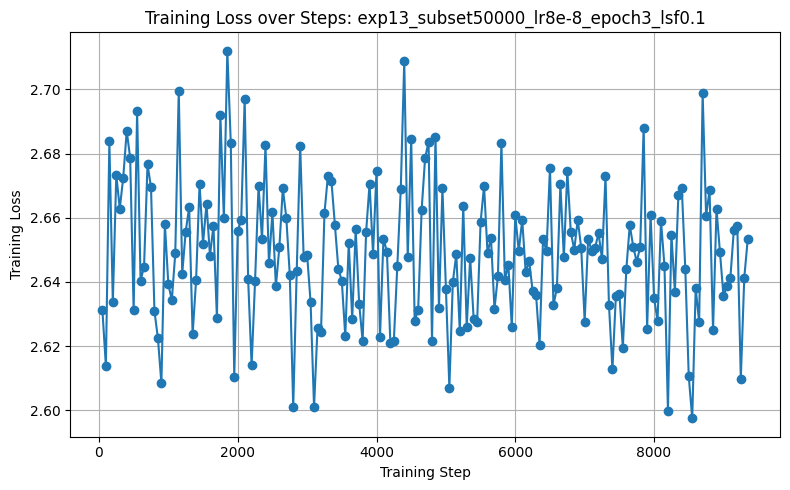

Saved training loss plot to: outputs\figures\exp13_subset50000_lr8e-8_epoch3_lsf0.1\training_loss.png


In [34]:
# =========================
# Plot Training Loss
# =========================

plt.figure(figsize=(8, 5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title(f"Training Loss over Steps: {RUN_ID}")
plt.grid(True)
plt.tight_layout()

loss_plot_path = EXPERIMENT_FIGURES_DIR / "training_loss.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved training loss plot to:", loss_plot_path)

## Fine-Tuned Development/Validation Evaluation

In [35]:
# =========================
# Reload Fine-Tuned Experiment Checkpoint
# =========================

fine_tuned_tokenizer = MarianTokenizer.from_pretrained(EXPERIMENT_CHECKPOINT_DIR)
fine_tuned_model = MarianMTModel.from_pretrained(EXPERIMENT_CHECKPOINT_DIR)
fine_tuned_model = fine_tuned_model.to(device)

print("Reloaded fine-tuned model from:", EXPERIMENT_CHECKPOINT_DIR)

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Reloaded fine-tuned model from: outputs\checkpoints\exp13_subset50000_lr8e-8_epoch3_lsf0.1


In [36]:
# =========================
# Fine-Tuned Dev Evaluation
# =========================

fine_tuned_dev_result = evaluate_translation_sacrebleu(
    dataset=dev_dataset,
    model=fine_tuned_model,
    tokenizer=fine_tuned_tokenizer,
    batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    max_source_length=MAX_SOURCE_LENGTH,
    num_beams=NUM_BEAMS,
    max_new_tokens=MAX_NEW_TOKENS,
    length_penalty=LENGTH_PENALTY,
    early_stopping=EARLY_STOPPING,
    device=device,
)

fine_tuned_dev_sacrebleu = fine_tuned_dev_result["sacrebleu"]

print("Fine-Tuned Dev SacreBLEU:", fine_tuned_dev_sacrebleu)

Fine-Tuned Dev SacreBLEU: 33.24900519591735


In [37]:
# =========================
# Save Fine-Tuned Dev Metrics
# =========================

fine_tuned_dev_metrics = {
    "run_id": RUN_ID,
    "model_name": MODEL_NAME,
    "split": "dev",
    "sacrebleu": fine_tuned_dev_sacrebleu,
    "num_examples": len(dev_dataset),
    "train_subset_size": TRAIN_SUBSET_SIZE,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "warmup_steps": WARMUP_STEPS,
    "label_smoothing_factor": LABEL_SMOOTHING_FACTOR,
    "num_beams": NUM_BEAMS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "length_penalty": LENGTH_PENALTY,
    "early_stopping": EARLY_STOPPING,
    "max_source_length": MAX_SOURCE_LENGTH,
    "max_target_length": MAX_TARGET_LENGTH,
    "checkpoint_path": str(EXPERIMENT_CHECKPOINT_DIR),
    "notes": "Fine-tuned Helsinki model evaluated on dev set.",
}

fine_tuned_dev_metrics_path = EXPERIMENT_METRICS_DIR / "dev_metrics.json"

with open(fine_tuned_dev_metrics_path, "w", encoding="utf-8") as f:
    json.dump(fine_tuned_dev_metrics, f, indent=2)

print("Saved fine-tuned dev metrics to:", fine_tuned_dev_metrics_path)

Saved fine-tuned dev metrics to: outputs\metrics\exp13_subset50000_lr8e-8_epoch3_lsf0.1\dev_metrics.json


In [38]:
# =========================
# Save Fine-Tuned Dev Translations
# =========================

fine_tuned_dev_translations_df = pd.DataFrame({
    "source": fine_tuned_dev_result["sources"],
    "reference": fine_tuned_dev_result["references"],
    "fine_tuned_prediction": fine_tuned_dev_result["predictions"],
})

fine_tuned_dev_translations_path = EXPERIMENT_TRANSLATIONS_DIR / "dev_translations.csv"

fine_tuned_dev_translations_df.to_csv(
    fine_tuned_dev_translations_path,
    index=False,
    encoding="utf-8"
)

print("Saved fine-tuned dev translations to:", fine_tuned_dev_translations_path)

fine_tuned_dev_translations_df.head()

Saved fine-tuned dev translations to: outputs\translations\exp13_subset50000_lr8e-8_epoch3_lsf0.1\dev_translations.csv


,source,reference,fine_tuned_prediction
0,The Beauty of Munich 2018: the Beauty of Munic...,Schöne Münchnerin 2018: Schöne Münchnerin 2018...,Die Schönheit Münchens 2018: Die Schönheit Mün...
1,"From A-Z, updated on 04/05/2018 at 11:11","Von az, aktualisiert am 04.05.2018 um 11:11","Von A-Z, aktualisiert am 04/05/2018 um 11:11"
2,"Yes, she wants to...","Ja, sie will...","Ja, sie will..."
3,"to become ""The Beauty of Munich"" in 2018!","""Schöne Münchnerin"" 2018 werden!","2018 ""Die Schönheit Münchens"" zu werden!"
4,In the afternoon there is another surprise wai...,Am Nachmittag wartet erneut eine Überraschung ...,Am Nachmittag wartet eine weitere Überraschung...


In [39]:
# =========================
# Experiment Summary Helper
# =========================

EXPERIMENT_SUMMARY_PATH = METRICS_DIR / "experiment_summary.csv"

def append_experiment_summary(row, summary_path=EXPERIMENT_SUMMARY_PATH):
    """
    Append a new experiment row to the summary table.
    If the run_id already exists, replace the old row with the new row.
    """
    if summary_path.exists():
        summary_df = pd.read_csv(summary_path)
    else:
        summary_df = pd.DataFrame()

    row_df = pd.DataFrame([row])

    if not summary_df.empty and "run_id" in summary_df.columns:
        summary_df = summary_df[summary_df["run_id"] != row["run_id"]]

    summary_df = pd.concat([summary_df, row_df], ignore_index=True)

    summary_df.to_csv(summary_path, index=False)

    print("Saved experiment summary to:", summary_path)

    return summary_df

In [40]:
# =========================
# Add / Update Baseline Summary Row
# =========================

baseline_metrics_path = BASELINE_METRICS_DIR / "baseline_dev_metrics.json"

with open(baseline_metrics_path, "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)

baseline_dev_sacrebleu = baseline_metrics["sacrebleu"]

baseline_summary_row = {
    "run_id": "baseline_helsinki",
    "changed_variable": "none - pretrained baseline",
    "training_subset_size": 0,
    "learning_rate": None,
    "batch_size": None,
    "epochs": 0,
    "beam_size": baseline_metrics["num_beams"],
    "dev_sacrebleu": baseline_metrics["sacrebleu"],
    "dev_vs_baseline": 0.0,
    "checkpoint_path": baseline_metrics["checkpoint_path"],
    "notes": baseline_metrics["notes"],
}

experiment_summary_df = append_experiment_summary(baseline_summary_row)

experiment_summary_df

Saved experiment summary to: outputs\metrics\experiment_summary.csv


,run_id,changed_variable,training_subset_size,learning_rate,batch_size,epochs,beam_size,dev_sacrebleu,dev_vs_baseline,checkpoint_path,notes
0,exp01_subset50000_lr2e-5,fine-tuning enabled,50000,0.00002,16.0,1,4,32.308711,-0.652388,outputs\checkpoints\exp01_subset50000_lr2e-5,Fine-tuned pretrained Helsinki model on traini...
1,exp02_subset50000_lr2e-5_epoch3,fine-tuning enabled,50000,0.00002,16.0,3,4,31.546998,-1.414101,outputs\checkpoints\exp02_subset50000_lr2e-5_e...,Fine-tuned pretrained Helsinki model on traini...
2,exp03_subset50000_lr1e-5_epoch1,fine-tuning enabled,50000,0.00001,16.0,1,4,32.571799,-0.389300,outputs\checkpoints\exp03_subset50000_lr1e-5_e...,Fine-tuned pretrained Helsinki model on traini...
3,exp04_subset50000_lr1e-6_epoch1,fine-tuning enabled,50000,0.000001,16.0,1,4,32.782435,-0.178664,outputs\checkpoints\exp04_subset50000_lr1e-6_e...,Fine-tuned pretrained Helsinki model on traini...
4,exp05_subset50000_lr5e-6_epoch1,fine-tuning enabled,50000,0.000005,16.0,1,4,32.787899,-0.173200,outputs\checkpoints\exp05_subset50000_lr5e-6_e...,Fine-tuned pretrained Helsinki model on traini...
5,exp06_subset50000_lr1e-7_epoch1,fine-tuning enabled,50000,0.0,16.0,1,4,32.916682,-0.044417,outputs\checkpoints\exp06_subset50000_lr1e-7_e...,Fine-tuned pretrained Helsinki model on traini...
6,exp07_subset50000_lr5e-8_epoch1,fine-tuning enabled,50000,0.0,16.0,1,4,32.957484,-0.003615,outputs\checkpoints\exp07_subset50000_lr5e-8_e...,Fine-tuned pretrained Helsinki model on traini...
7,exp08_subset50000_lr8e-8_epoch1,fine-tuning enabled,50000,0.0,16.0,1,4,32.990407,0.029308,outputs\checkpoints\exp08_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...
8,exp09_subset50000_lr8e-8_epoch2,fine-tuning enabled,50000,0.0,16.0,2,4,33.120549,0.159450,outputs\checkpoints\exp09_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...
9,exp10_subset50000_lr8e-8_epoch3,fine-tuning enabled,50000,0.0,16.0,3,4,33.147454,0.186355,outputs\checkpoints\exp10_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...


In [41]:
# =========================
# Add / Update Fine-Tuned Experiment Summary Row
# =========================

experiment_summary_row = {
    "run_id": RUN_ID,
    "changed_variable": experiment_config["changed_variable"],
    "training_subset_size": TRAIN_SUBSET_SIZE,
    "learning_rate": LEARNING_RATE,
    "batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "beam_size": NUM_BEAMS,
    "dev_sacrebleu": fine_tuned_dev_sacrebleu,
    "dev_vs_baseline": fine_tuned_dev_sacrebleu - baseline_dev_sacrebleu,
    "checkpoint_path": str(EXPERIMENT_CHECKPOINT_DIR),
    "notes": "Fine-tuned pretrained Helsinki model on training subset.",
}

experiment_summary_df = append_experiment_summary(experiment_summary_row)

experiment_summary_df

Saved experiment summary to: outputs\metrics\experiment_summary.csv


,run_id,changed_variable,training_subset_size,learning_rate,batch_size,epochs,beam_size,dev_sacrebleu,dev_vs_baseline,checkpoint_path,notes
0,exp01_subset50000_lr2e-5,fine-tuning enabled,50000,2.000000e-05,16.0,1,4,32.308711,-0.652388,outputs\checkpoints\exp01_subset50000_lr2e-5,Fine-tuned pretrained Helsinki model on traini...
1,exp02_subset50000_lr2e-5_epoch3,fine-tuning enabled,50000,2.000000e-05,16.0,3,4,31.546998,-1.414101,outputs\checkpoints\exp02_subset50000_lr2e-5_e...,Fine-tuned pretrained Helsinki model on traini...
2,exp03_subset50000_lr1e-5_epoch1,fine-tuning enabled,50000,1.000000e-05,16.0,1,4,32.571799,-0.389300,outputs\checkpoints\exp03_subset50000_lr1e-5_e...,Fine-tuned pretrained Helsinki model on traini...
3,exp04_subset50000_lr1e-6_epoch1,fine-tuning enabled,50000,1.000000e-06,16.0,1,4,32.782435,-0.178664,outputs\checkpoints\exp04_subset50000_lr1e-6_e...,Fine-tuned pretrained Helsinki model on traini...
4,exp05_subset50000_lr5e-6_epoch1,fine-tuning enabled,50000,5.000000e-06,16.0,1,4,32.787899,-0.173200,outputs\checkpoints\exp05_subset50000_lr5e-6_e...,Fine-tuned pretrained Helsinki model on traini...
5,exp06_subset50000_lr1e-7_epoch1,fine-tuning enabled,50000,1.000000e-07,16.0,1,4,32.916682,-0.044417,outputs\checkpoints\exp06_subset50000_lr1e-7_e...,Fine-tuned pretrained Helsinki model on traini...
6,exp07_subset50000_lr5e-8_epoch1,fine-tuning enabled,50000,5.000000e-08,16.0,1,4,32.957484,-0.003615,outputs\checkpoints\exp07_subset50000_lr5e-8_e...,Fine-tuned pretrained Helsinki model on traini...
7,exp08_subset50000_lr8e-8_epoch1,fine-tuning enabled,50000,8.000000e-08,16.0,1,4,32.990407,0.029308,outputs\checkpoints\exp08_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...
8,exp09_subset50000_lr8e-8_epoch2,fine-tuning enabled,50000,8.000000e-08,16.0,2,4,33.120549,0.159450,outputs\checkpoints\exp09_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...
9,exp10_subset50000_lr8e-8_epoch3,fine-tuning enabled,50000,8.000000e-08,16.0,3,4,33.147454,0.186355,outputs\checkpoints\exp10_subset50000_lr8e-8_e...,Fine-tuned pretrained Helsinki model on traini...


In [42]:
# =========================
# Save Experiment Summary Table
# =========================

experiment_summary_path = METRICS_DIR / "experiment_summary.csv"

experiment_summary_df.to_csv(experiment_summary_path, index=False)

print("Saved experiment summary to:", experiment_summary_path)

Saved experiment summary to: outputs\metrics\experiment_summary.csv


In [43]:
print("Baseline Dev SacreBLEU:", baseline_dev_sacrebleu)
print("Fine-Tuned Dev SacreBLEU:", fine_tuned_dev_sacrebleu)

Baseline Dev SacreBLEU: 32.96109890363845
Fine-Tuned Dev SacreBLEU: 33.24900519591735


## Sample Transitions

In [44]:
# =========================
# Load Saved Baseline and Current Fine-Tuned Translations
# =========================

CURRENT_RUN_ID = RUN_ID

baseline_translations_path = TRANSLATIONS_DIR / "baseline_dev_translations.csv"
current_translations_path = EXPERIMENT_TRANSLATIONS_DIR / "dev_translations.csv"

baseline_translations_df = pd.read_csv(baseline_translations_path)
current_translations_df = pd.read_csv(current_translations_path)

print("Current run ID:", CURRENT_RUN_ID)
print("Baseline translations:", baseline_translations_df.shape)
print("Current fine-tuned translations:", current_translations_df.shape)

Current run ID: exp13_subset50000_lr8e-8_epoch3_lsf0.1
Baseline translations: (2000, 3)
Current fine-tuned translations: (2000, 3)


In [45]:
# =========================
# Build Sample Translation Comparison Table
# =========================

sample_indices = [0, 1, 2, 3, 4]

sample_translation_rows = []

for idx in sample_indices:
    sample_translation_rows.append({
        "example_id": idx,
        "source": baseline_translations_df.loc[idx, "source"],
        "reference": baseline_translations_df.loc[idx, "reference"],
        "baseline_prediction": baseline_translations_df.loc[idx, "baseline_prediction"],
        "fine_tuned_prediction": current_translations_df.loc[idx, "fine_tuned_prediction"],
    })

sample_translations_df = pd.DataFrame(sample_translation_rows)

sample_translations_df

,example_id,source,reference,baseline_prediction,fine_tuned_prediction
0,0,The Beauty of Munich 2018: the Beauty of Munic...,Schöne Münchnerin 2018: Schöne Münchnerin 2018...,Die Schönheit Münchens 2018: Die Schönheit Mün...,Die Schönheit Münchens 2018: Die Schönheit Mün...
1,1,"From A-Z, updated on 04/05/2018 at 11:11","Von az, aktualisiert am 04.05.2018 um 11:11","Von A-Z, aktualisiert am 04/05/2018 um 11:11","Von A-Z, aktualisiert am 04/05/2018 um 11:11"
2,2,"Yes, she wants to...","Ja, sie will...","Ja, sie will...","Ja, sie will..."
3,3,"to become ""The Beauty of Munich"" in 2018!","""Schöne Münchnerin"" 2018 werden!","2018 zur ""Schönheit Münchens""!","2018 ""Die Schönheit Münchens"" zu werden!"
4,4,In the afternoon there is another surprise wai...,Am Nachmittag wartet erneut eine Überraschung ...,Am Nachmittag wartet eine weitere Überraschung...,Am Nachmittag wartet eine weitere Überraschung...


In [46]:
# =========================
# Create Vertical Sample Translation Display
# =========================

vertical_rows = []

for _, row in sample_translations_df.iterrows():
    example_id = row["example_id"]
    
    vertical_rows.extend([
        {
            "example_id": example_id,
            "field": "Source English",
            "text": row["source"],
        },
        {
            "example_id": example_id,
            "field": "Reference German",
            "text": row["reference"],
        },
        {
            "example_id": example_id,
            "field": "Baseline Prediction",
            "text": row["baseline_prediction"],
        },
        {
            "example_id": example_id,
            "field": "Fine-Tuned Prediction",
            "text": row["fine_tuned_prediction"],
        },
    ])

vertical_sample_translations_df = pd.DataFrame(vertical_rows)

vertical_sample_translations_df

,example_id,field,text
0,0,Source English,The Beauty of Munich 2018: the Beauty of Munic...
1,0,Reference German,Schöne Münchnerin 2018: Schöne Münchnerin 2018...
2,0,Baseline Prediction,Die Schönheit Münchens 2018: Die Schönheit Mün...
3,0,Fine-Tuned Prediction,Die Schönheit Münchens 2018: Die Schönheit Mün...
4,1,Source English,"From A-Z, updated on 04/05/2018 at 11:11"
5,1,Reference German,"Von az, aktualisiert am 04.05.2018 um 11:11"
6,1,Baseline Prediction,"Von A-Z, aktualisiert am 04/05/2018 um 11:11"
7,1,Fine-Tuned Prediction,"Von A-Z, aktualisiert am 04/05/2018 um 11:11"
8,2,Source English,"Yes, she wants to..."
9,2,Reference German,"Ja, sie will..."


In [47]:
# =========================
# Save Vertical Sample Translation Table
# =========================

vertical_sample_translations_path = EXPERIMENT_TRANSLATIONS_DIR / "sample_translation_comparison_vertical.csv"

vertical_sample_translations_df.to_csv(
    vertical_sample_translations_path,
    index=False,
    encoding="utf-8"
)

print("Saved vertical sample translation comparison to:", vertical_sample_translations_path)

Saved vertical sample translation comparison to: outputs\translations\exp13_subset50000_lr8e-8_epoch3_lsf0.1\sample_translation_comparison_vertical.csv


In [48]:
## Attention Visualization

In [49]:
# =========================
# Use Current Checkpoint with Eager Attention for Visualization
# =========================

attention_checkpoint_dir = EXPERIMENT_CHECKPOINT_DIR

attention_tokenizer = MarianTokenizer.from_pretrained(attention_checkpoint_dir)

attention_model = MarianMTModel.from_pretrained(
    attention_checkpoint_dir,
    attn_implementation="eager",
)

# Avoid warning when generate() uses max_new_tokens.
attention_model.generation_config.max_length = None

attention_model = attention_model.to(device)
attention_model.eval()

print("Loaded model with eager attention for visualization from:", attention_checkpoint_dir)

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded model with eager attention for visualization from: outputs\checkpoints\exp13_subset50000_lr8e-8_epoch3_lsf0.1


In [50]:
# =========================
# Select Example for Attention Visualization
# =========================

attention_example_index = 0

attention_source_text = dev_dataset[attention_example_index]["source"]
attention_reference_text = dev_dataset[attention_example_index]["reference"]

print("Source English:")
print(attention_source_text)
print()

print("Reference German:")
print(attention_reference_text)

Source English:
The Beauty of Munich 2018: the Beauty of Munich 2018 in Hvar: Nine dates

Reference German:
Schöne Münchnerin 2018: Schöne Münchnerin 2018 in Hvar: Neun Dates


In [51]:
# =========================
# Generate Translation for Attention Example
# =========================

encoded_source = attention_tokenizer(
    attention_source_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=MAX_SOURCE_LENGTH,
).to(device)

with torch.no_grad():
    generated_ids = attention_model.generate(
        **encoded_source,
        num_beams=NUM_BEAMS,
        max_new_tokens=MAX_NEW_TOKENS,
        length_penalty=LENGTH_PENALTY,
        early_stopping=EARLY_STOPPING,
    )

generated_translation = attention_tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Generated German translation:")
print(generated_translation)

Generated German translation:
Die Schönheit Münchens 2018: Die Schönheit Münchens 2018 in Hvar: Neun Termine


In [52]:
# =========================
# Extract Decoder Cross-Attention
# =========================

# Make sure attentions are enabled.
attention_model.config.output_attentions = True
attention_model.config.return_dict = True

# Use the generated translation as decoder input so we can inspect cross-attention.
decoder_input_ids = generated_ids[:, :-1]

with torch.no_grad():
    attention_outputs = attention_model(
        input_ids=encoded_source["input_ids"],
        attention_mask=encoded_source["attention_mask"],
        decoder_input_ids=decoder_input_ids,
        output_attentions=True,
        return_dict=True,
    )

cross_attentions = attention_outputs.cross_attentions

if cross_attentions is None or len(cross_attentions) == 0:
    raise ValueError(
        "No cross-attention tensors were returned. "
        "Try using output_attentions=True, return_dict=True, and make sure the model is in eval mode."
    )

print("Number of decoder layers with cross-attention:", len(cross_attentions))
print("Last layer cross-attention shape:", cross_attentions[-1].shape)

Number of decoder layers with cross-attention: 6
Last layer cross-attention shape: torch.Size([1, 8, 18, 18])


In [53]:
# =========================
# Prepare Attention Matrix
# =========================

# Use the last decoder layer and average across attention heads.
last_layer_attention = cross_attentions[-1][0]  # shape: heads x target_len x source_len
average_attention = last_layer_attention.mean(dim=0).detach().cpu().numpy()

source_token_ids = encoded_source["input_ids"][0].detach().cpu().tolist()
target_token_ids = decoder_input_ids[0].detach().cpu().tolist()

source_tokens = attention_tokenizer.convert_ids_to_tokens(source_token_ids)
target_tokens = attention_tokenizer.convert_ids_to_tokens(target_token_ids)

# Remove padding tokens from source side for cleaner visualization.
non_pad_source_indices = [
    i for i, token_id in enumerate(source_token_ids)
    if token_id != attention_tokenizer.pad_token_id
]

source_tokens_clean = [source_tokens[i] for i in non_pad_source_indices]
attention_clean = average_attention[:, non_pad_source_indices]

print("Source tokens:", source_tokens_clean)
print("Target tokens:", target_tokens)

Source tokens: ['▁The', '▁Beauty', '▁of', '▁Munich', '▁2018', ':', '▁the', '▁Beauty', '▁of', '▁Munich', '▁2018', '▁in', '▁H', 'var', ':', '▁Nine', '▁dates', '</s>']
Target tokens: ['<pad>', '▁Die', '▁Schönheit', '▁München', 's', '▁2018', ':', '▁Die', '▁Schönheit', '▁München', 's', '▁2018', '▁in', '▁H', 'var', ':', '▁Neun', '▁Termine']


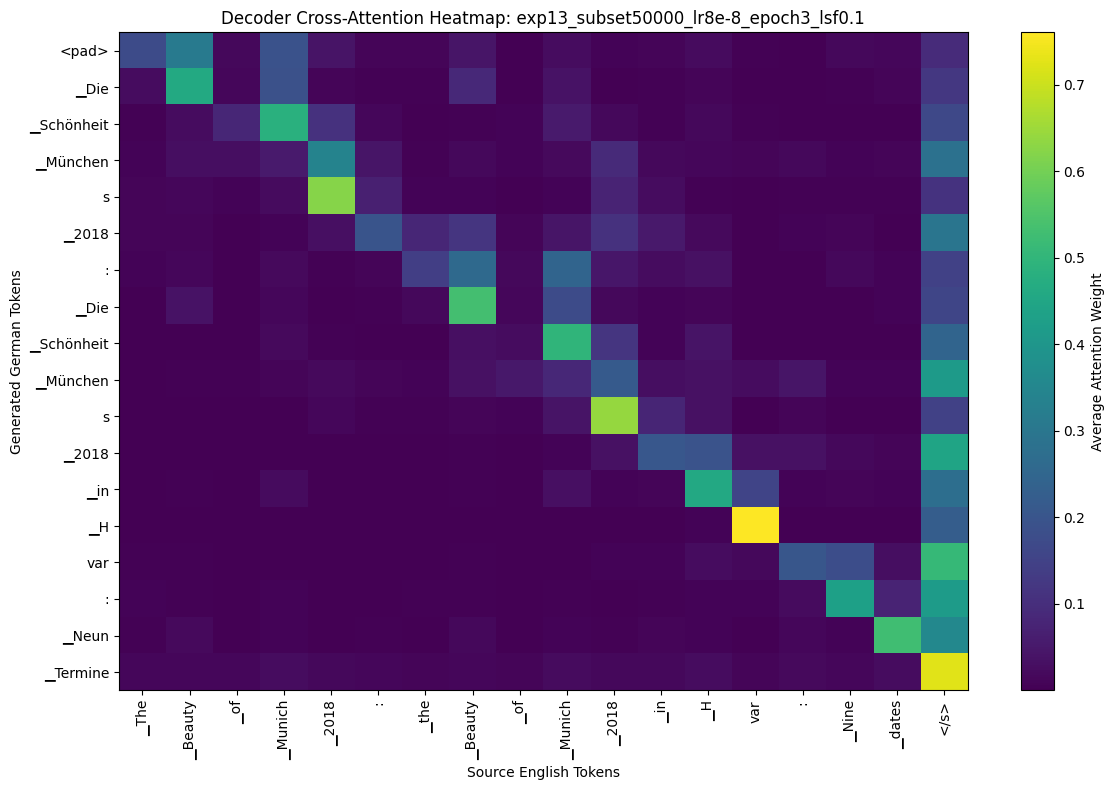

Saved attention heatmap to: outputs\figures\exp13_subset50000_lr8e-8_epoch3_lsf0.1\cross_attention_heatmap.png


In [54]:
# =========================
# Plot Cross-Attention Heatmap
# =========================

plt.figure(figsize=(12, 8))

plt.imshow(attention_clean, aspect="auto")

plt.xticks(
    ticks=np.arange(len(source_tokens_clean)),
    labels=source_tokens_clean,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(target_tokens)),
    labels=target_tokens
)

plt.xlabel("Source English Tokens")
plt.ylabel("Generated German Tokens")
plt.title(f"Decoder Cross-Attention Heatmap: {RUN_ID}")

plt.colorbar(label="Average Attention Weight")
plt.tight_layout()

attention_plot_path = EXPERIMENT_FIGURES_DIR / "cross_attention_heatmap.png"

plt.savefig(attention_plot_path, dpi=200)
plt.show()

print("Saved attention heatmap to:", attention_plot_path)

# Final Model and Configuration
From this point onward, all code will be inactive until we have found our best model

# =========================
# Load Experiment Summary Table
# =========================

EXPERIMENT_SUMMARY_PATH = METRICS_DIR / "experiment_summary.csv"

experiment_summary_df = pd.read_csv(EXPERIMENT_SUMMARY_PATH)

experiment_summary_df

# =========================
# Select Best Dev Experiment
# =========================

fine_tuned_experiments_df = experiment_summary_df[
    experiment_summary_df["run_id"] != "baseline_helsinki"
].copy()

best_dev_row = fine_tuned_experiments_df.sort_values(
    by="dev_sacrebleu",
    ascending=False
).iloc[0]

FINAL_SELECTED_RUN_ID = best_dev_row["run_id"]
FINAL_SELECTED_CHECKPOINT_DIR = Path(best_dev_row["checkpoint_path"])

print("Final selected run ID:", FINAL_SELECTED_RUN_ID)
print("Final selected dev SacreBLEU:", best_dev_row["dev_sacrebleu"])
print("Final selected checkpoint:", FINAL_SELECTED_CHECKPOINT_DIR)

# =========================
# Save Final Experiment Selection
# =========================

final_selection = {
    "final_selected_run_id": FINAL_SELECTED_RUN_ID,
    "final_selected_checkpoint_dir": str(FINAL_SELECTED_CHECKPOINT_DIR),
    "selection_metric": "dev_sacrebleu",
    "selected_dev_sacrebleu": float(best_dev_row["dev_sacrebleu"]),
    "baseline_dev_sacrebleu": float(
        experiment_summary_df.loc[
            experiment_summary_df["run_id"] == "baseline_helsinki",
            "dev_sacrebleu"
        ].iloc[0]
    ),
    "notes": (
        "Final model selected using development SacreBLEU. "
        "The test set was not used for model selection."
    ),
}

final_selection_path = METRICS_DIR / "final_experiment_selection.json"

with open(final_selection_path, "w", encoding="utf-8") as f:
    json.dump(final_selection, f, indent=2)

print("Saved final experiment selection to:", final_selection_path)

## Final Test Evaluation

# =========================
# Reload Final Selected Model
# =========================

with open(METRICS_DIR / "final_experiment_selection.json", "r", encoding="utf-8") as f:
    final_selection = json.load(f)

FINAL_SELECTED_RUN_ID = final_selection["final_selected_run_id"]
FINAL_SELECTED_CHECKPOINT_DIR = Path(final_selection["final_selected_checkpoint_dir"])

final_tokenizer = MarianTokenizer.from_pretrained(FINAL_SELECTED_CHECKPOINT_DIR)
final_model = MarianMTModel.from_pretrained(FINAL_SELECTED_CHECKPOINT_DIR)

# Avoid warning when generate() uses max_new_tokens.
final_model.generation_config.max_length = None

final_model = final_model.to(device)
final_model.eval()

print("Reloaded final selected model.")
print("Final selected run ID:", FINAL_SELECTED_RUN_ID)
print("Checkpoint:", FINAL_SELECTED_CHECKPOINT_DIR)

# =========================
# Final Test Evaluation
# =========================

final_test_result = evaluate_translation_sacrebleu(
    dataset=test_dataset,
    model=final_model,
    tokenizer=final_tokenizer,
    batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    max_source_length=MAX_SOURCE_LENGTH,
    num_beams=NUM_BEAMS,
    max_new_tokens=MAX_NEW_TOKENS,
    length_penalty=LENGTH_PENALTY,
    early_stopping=EARLY_STOPPING,
    device=device,
)

final_test_sacrebleu = final_test_result["sacrebleu"]

print("Final Test SacreBLEU:", final_test_sacrebleu)

# =========================
# Save Final Test Metrics
# =========================

final_test_metrics = {
    "run_id": FINAL_SELECTED_RUN_ID,
    "split": "test",
    "sacrebleu": final_test_sacrebleu,
    "num_examples": len(test_dataset),
    "num_beams": NUM_BEAMS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "length_penalty": LENGTH_PENALTY,
    "early_stopping": EARLY_STOPPING,
    "max_source_length": MAX_SOURCE_LENGTH,
    "checkpoint_path": str(FINAL_SELECTED_CHECKPOINT_DIR),
    "notes": "Final selected model evaluated once on the held-out test set.",
}

FINAL_METRICS_DIR = METRICS_DIR / "final_test"
FINAL_METRICS_DIR.mkdir(parents=True, exist_ok=True)

final_test_metrics_path = FINAL_METRICS_DIR / "test_metrics.json"

with open(final_test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(final_test_metrics, f, indent=2)

print("Saved final test metrics to:", final_test_metrics_path)

# =========================
# Save Final Test Translations - Vertical Format
# =========================

FINAL_TRANSLATIONS_DIR = TRANSLATIONS_DIR / "final_test"
FINAL_TRANSLATIONS_DIR.mkdir(parents=True, exist_ok=True)

final_test_vertical_rows = []

for idx in range(len(final_test_result["sources"])):
    final_test_vertical_rows.extend([
        {
            "example_id": idx,
            "field": "Source English",
            "text": final_test_result["sources"][idx],
        },
        {
            "example_id": idx,
            "field": "Reference German",
            "text": final_test_result["references"][idx],
        },
        {
            "example_id": idx,
            "field": "Final Model Prediction",
            "text": final_test_result["predictions"][idx],
        },
    ])

final_test_translations_vertical_df = pd.DataFrame(final_test_vertical_rows)

final_test_translations_path = FINAL_TRANSLATIONS_DIR / "test_translations_vertical.csv"

final_test_translations_vertical_df.to_csv(
    final_test_translations_path,
    index=False,
    encoding="utf-8"
)

print("Saved final test translations in vertical format to:", final_test_translations_path)

# =========================
# Display Final Test Translation Samples
# =========================

pd.set_option("display.max_colwidth", None)

final_test_sample_vertical_df = final_test_translations_vertical_df[
    final_test_translations_vertical_df["example_id"].isin([0, 1, 2, 3, 4])
]

styled_final_test_samples = (
    final_test_sample_vertical_df
    .style
    .set_properties(
        subset=["text"],
        **{
            "text-align": "left",
            "white-space": "pre-wrap",
            "max-width": "900px",
        }
    )
    .set_properties(
        subset=["field"],
        **{
            "font-weight": "bold",
            "text-align": "left",
            "width": "180px",
        }
    )
    .hide(axis="index")
)

styled_final_test_samples

# =========================
# Save Final Selected Model Copy
# =========================

FINAL_MODEL_DIR = CHECKPOINT_DIR / "final_selected_model"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_model.save_pretrained(FINAL_MODEL_DIR)
final_tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("Saved final selected model copy to:", FINAL_MODEL_DIR)

## Final Test Attention Visualization

# =========================
# Load Final Selected Model with Eager Attention
# =========================

with open(METRICS_DIR / "final_experiment_selection.json", "r", encoding="utf-8") as f:
    final_selection = json.load(f)

FINAL_SELECTED_RUN_ID = final_selection["final_selected_run_id"]
FINAL_SELECTED_CHECKPOINT_DIR = Path(final_selection["final_selected_checkpoint_dir"])

final_attention_tokenizer = MarianTokenizer.from_pretrained(FINAL_SELECTED_CHECKPOINT_DIR)

final_attention_model = MarianMTModel.from_pretrained(
    FINAL_SELECTED_CHECKPOINT_DIR,
    attn_implementation="eager",
)

# Avoid warning when generate() uses max_new_tokens.
final_attention_model.generation_config.max_length = None

final_attention_model = final_attention_model.to(device)
final_attention_model.eval()

print("Loaded final selected model with eager attention.")
print("Final selected run ID:", FINAL_SELECTED_RUN_ID)
print("Checkpoint:", FINAL_SELECTED_CHECKPOINT_DIR)

# =========================
# Select Test Example for Attention Visualization
# =========================

final_attention_example_index = 0

final_attention_source_text = test_dataset[final_attention_example_index]["source"]
final_attention_reference_text = test_dataset[final_attention_example_index]["reference"]

print("Test example index:", final_attention_example_index)
print()
print("Source English:")
print(final_attention_source_text)
print()
print("Reference German:")
print(final_attention_reference_text)

# =========================
# Generate Translation for Final Attention Example
# =========================

final_encoded_source = final_attention_tokenizer(
    final_attention_source_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=MAX_SOURCE_LENGTH,
).to(device)

with torch.no_grad():
    final_generated_ids = final_attention_model.generate(
        **final_encoded_source,
        num_beams=NUM_BEAMS,
        max_new_tokens=MAX_NEW_TOKENS,
        length_penalty=LENGTH_PENALTY,
        early_stopping=EARLY_STOPPING,
    )

final_generated_translation = final_attention_tokenizer.batch_decode(
    final_generated_ids,
    skip_special_tokens=True,
)[0]

print("Generated German translation:")
print(final_generated_translation)

# =========================
# Extract Final Decoder Cross-Attention
# =========================

final_attention_model.config.output_attentions = True
final_attention_model.config.return_dict = True
final_attention_model.eval()

# Use the generated translation as decoder input.
final_decoder_input_ids = final_generated_ids[:, :-1]

with torch.no_grad():
    final_attention_outputs = final_attention_model(
        input_ids=final_encoded_source["input_ids"],
        attention_mask=final_encoded_source["attention_mask"],
        decoder_input_ids=final_decoder_input_ids,
        output_attentions=True,
        return_dict=True,
    )

final_cross_attentions = final_attention_outputs.cross_attentions

if final_cross_attentions is None or len(final_cross_attentions) == 0:
    raise ValueError("No cross-attention tensors were returned.")

print("Number of decoder layers with cross-attention:", len(final_cross_attentions))
print("Last layer cross-attention shape:", final_cross_attentions[-1].shape)

# =========================
# Prepare Final Attention Matrix
# =========================

# Use the last decoder layer and average across attention heads.
final_last_layer_attention = final_cross_attentions[-1][0]
final_average_attention = final_last_layer_attention.mean(dim=0).detach().cpu().numpy()

final_source_token_ids = final_encoded_source["input_ids"][0].detach().cpu().tolist()
final_target_token_ids = final_decoder_input_ids[0].detach().cpu().tolist()

final_source_tokens = final_attention_tokenizer.convert_ids_to_tokens(final_source_token_ids)
final_target_tokens = final_attention_tokenizer.convert_ids_to_tokens(final_target_token_ids)

# Remove padding tokens from source side.
final_non_pad_source_indices = [
    i for i, token_id in enumerate(final_source_token_ids)
    if token_id != final_attention_tokenizer.pad_token_id
]

final_source_tokens_clean = [
    final_source_tokens[i]
    for i in final_non_pad_source_indices
]

final_attention_clean = final_average_attention[:, final_non_pad_source_indices]

print("Source tokens:", final_source_tokens_clean)
print("Target tokens:", final_target_tokens)

# =========================
# Plot Final Test Cross-Attention Heatmap
# =========================

FINAL_FIGURES_DIR = FIGURES_DIR / "final_test"
FINAL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 8))

plt.imshow(final_attention_clean, aspect="auto")

plt.xticks(
    ticks=np.arange(len(final_source_tokens_clean)),
    labels=final_source_tokens_clean,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(final_target_tokens)),
    labels=final_target_tokens,
)

plt.xlabel("Source English Tokens")
plt.ylabel("Generated German Tokens")
plt.title(f"Final Model Decoder Cross-Attention Heatmap: {FINAL_SELECTED_RUN_ID}")

plt.colorbar(label="Average Attention Weight")
plt.tight_layout()

final_attention_plot_path = FINAL_FIGURES_DIR / "final_test_cross_attention_heatmap.png"

plt.savefig(final_attention_plot_path, dpi=200)
plt.show()

print("Saved final test attention heatmap to:", final_attention_plot_path)

## SacreBLEU Comparison Plot Across All Experiments

# =========================
# SacreBLEU Comparison Plot Across Experiments
# =========================

experiment_summary_df = pd.read_csv(EXPERIMENT_SUMMARY_PATH)

with open(METRICS_DIR / "final_experiment_selection.json", "r", encoding="utf-8") as f:
    final_selection = json.load(f)

FINAL_SELECTED_RUN_ID = final_selection["final_selected_run_id"]

plot_df = experiment_summary_df.copy()

# Optional: keep chronological/original experiment order if available from CSV.
# If you prefer highest-to-lowest, use:
# plot_df = plot_df.sort_values("dev_sacrebleu", ascending=False)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    plot_df["run_id"],
    plot_df["dev_sacrebleu"]
)

# Highlight the final selected model.
for bar, run_id in zip(bars, plot_df["run_id"]):
    if run_id == FINAL_SELECTED_RUN_ID:
        bar.set_hatch("//")
        bar.set_linewidth(2)

# Set BLEU scale and add project goal reference line.
plt.ylim(0, 100)
plt.axhline(
    y=80,
    linestyle=":",
    linewidth=2,
    label="Project goal reference: 80 BLEU"
)

plt.xlabel("Experiment")
plt.ylabel("Development SacreBLEU")
plt.title("Development SacreBLEU Across Baseline and Fine-Tuning Experiments w/ respect to goal and highest score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

sacrebleu_plot_path = FIGURES_DIR / "sacrebleu_dev_experiment_comparison.png"
plt.savefig(sacrebleu_plot_path, dpi=200)
plt.show()

print("Saved SacreBLEU comparison plot to:", sacrebleu_plot_path)

# =========================
# Zoomed-In SacreBLEU Comparison Plot Across Experiments
# =========================

experiment_summary_df = pd.read_csv(EXPERIMENT_SUMMARY_PATH)

with open(METRICS_DIR / "final_experiment_selection.json", "r", encoding="utf-8") as f:
    final_selection = json.load(f)

FINAL_SELECTED_RUN_ID = final_selection["final_selected_run_id"]

plot_df = experiment_summary_df.copy()

score_min = plot_df["dev_sacrebleu"].min()
score_max = plot_df["dev_sacrebleu"].max()

y_lower = max(0, score_min - 0.5)
y_upper = score_max + 0.5

plt.figure(figsize=(12, 6))

bars = plt.bar(
    plot_df["run_id"],
    plot_df["dev_sacrebleu"]
)

for bar, run_id in zip(bars, plot_df["run_id"]):
    if run_id == FINAL_SELECTED_RUN_ID:
        bar.set_hatch("//")
        bar.set_linewidth(2)

plt.ylim(y_lower, y_upper)

plt.xlabel("Experiment")
plt.ylabel("Development SacreBLEU")
plt.title("Zoomed-In Development SacreBLEU Across Experiments")
plt.xticks(rotation=45, ha="right")

# Add score labels.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0,
    )

plt.tight_layout()

zoomed_sacrebleu_plot_path = FIGURES_DIR / "sacrebleu_dev_experiment_comparison_zoomed.png"
plt.savefig(zoomed_sacrebleu_plot_path, dpi=200)
plt.show()

print("Saved zoomed SacreBLEU comparison plot to:", zoomed_sacrebleu_plot_path)

# Final Score Comparison Table

# =========================
# Robust Final Test Score Extraction
# =========================

final_test_score = (
    final_test_metrics.get("sacrebleu")
    or final_test_metrics.get("test_sacrebleu")
    or final_test_metrics.get("score")
)

print("Final test score:", final_test_score)

# =========================
# Build Final Score Comparison Table
# =========================

# Load experiment summary.
experiment_summary_df = pd.read_csv(EXPERIMENT_SUMMARY_PATH)

# Load final selection.
with open(METRICS_DIR / "final_experiment_selection.json", "r", encoding="utf-8") as f:
    final_selection = json.load(f)

FINAL_SELECTED_RUN_ID = final_selection["final_selected_run_id"]

# Load final test metrics.
FINAL_METRICS_DIR = METRICS_DIR / "final_test"
final_test_metrics_path = FINAL_METRICS_DIR / "test_metrics.json"

with open(final_test_metrics_path, "r", encoding="utf-8") as f:
    final_test_metrics = json.load(f)

# Get baseline row.
baseline_row = experiment_summary_df[
    experiment_summary_df["run_id"] == "baseline_helsinki"
].iloc[0]

# Get best dev row.
fine_tuned_experiments_df = experiment_summary_df[
    experiment_summary_df["run_id"] != "baseline_helsinki"
].copy()

best_dev_row = fine_tuned_experiments_df.sort_values(
    by="dev_sacrebleu",
    ascending=False
).iloc[0]

baseline_dev_score = baseline_row["dev_sacrebleu"]
best_dev_score = best_dev_row["dev_sacrebleu"]
final_test_score = final_test_metrics["sacrebleu"]

final_score_comparison_df = pd.DataFrame([
    {
        "result_type": "Baseline Dev",
        "run_id": baseline_row["run_id"],
        "split": "dev",
        "changed_variable": baseline_row.get("changed_variable", "none - pretrained baseline"),

        # Scores
        "sacrebleu": baseline_dev_score,
        "difference_vs_baseline_dev": 0.0,

        # Training hyperparameters
        "training_subset_size": baseline_row.get("training_subset_size", 0),
        "learning_rate": baseline_row.get("learning_rate", None),
        "per_device_train_batch_size": baseline_row.get("batch_size", None),
        "per_device_eval_batch_size": None,
        "gradient_accumulation_steps": None,
        "effective_batch_size": None,
        "epochs": baseline_row.get("epochs", 0),
        "weight_decay": None,
        "warmup_ratio": None,
        "warmup_steps": None,
        "label_smoothing_factor": None,
        "fp16": None,
        "group_by_length_or_sortish_sampler": None,

        # Sequence length / preprocessing
        "max_source_length": final_test_metrics.get("max_source_length", MAX_SOURCE_LENGTH),
        "max_target_length": MAX_TARGET_LENGTH,

        # Generation hyperparameters
        "beam_size": baseline_row.get("beam_size", NUM_BEAMS),
        "max_new_tokens": final_test_metrics.get("max_new_tokens", MAX_NEW_TOKENS),
        "length_penalty": final_test_metrics.get("length_penalty", LENGTH_PENALTY),
        "early_stopping": final_test_metrics.get("early_stopping", EARLY_STOPPING),

        # Checkpoint / notes
        "checkpoint_path": baseline_row["checkpoint_path"],
        "notes": "Pretrained baseline evaluated on development set.",
    },
    {
        "result_type": "Best Fine-Tuned Dev",
        "run_id": best_dev_row["run_id"],
        "split": "dev",
        "changed_variable": best_dev_row.get("changed_variable", ""),

        # Scores
        "sacrebleu": best_dev_score,
        "difference_vs_baseline_dev": best_dev_score - baseline_dev_score,

        # Training hyperparameters
        "training_subset_size": best_dev_row.get("training_subset_size"),
        "learning_rate": best_dev_row.get("learning_rate"),
        "per_device_train_batch_size": best_dev_row.get("batch_size"),
        "per_device_eval_batch_size": best_dev_row.get("per_device_eval_batch_size", PER_DEVICE_EVAL_BATCH_SIZE),
        "gradient_accumulation_steps": best_dev_row.get("gradient_accumulation_steps", GRADIENT_ACCUMULATION_STEPS),
        "effective_batch_size": (
            best_dev_row.get("batch_size") * best_dev_row.get("gradient_accumulation_steps", GRADIENT_ACCUMULATION_STEPS)
            if pd.notna(best_dev_row.get("batch_size")) else None
        ),
        "epochs": best_dev_row.get("epochs"),
        "weight_decay": best_dev_row.get("weight_decay", WEIGHT_DECAY),
        "warmup_ratio": best_dev_row.get("warmup_ratio", WARMUP_RATIO),
        "warmup_steps": best_dev_row.get("warmup_steps", None),
        "label_smoothing_factor": best_dev_row.get("label_smoothing_factor", LABEL_SMOOTHING_FACTOR),
        "fp16": best_dev_row.get("fp16", FP16),
        "group_by_length_or_sortish_sampler": best_dev_row.get("group_by_length", GROUP_BY_LENGTH),

        # Sequence length / preprocessing
        "max_source_length": best_dev_row.get("max_source_length", MAX_SOURCE_LENGTH),
        "max_target_length": best_dev_row.get("max_target_length", MAX_TARGET_LENGTH),

        # Generation hyperparameters
        "beam_size": best_dev_row.get("beam_size", NUM_BEAMS),
        "max_new_tokens": best_dev_row.get("max_new_tokens", MAX_NEW_TOKENS),
        "length_penalty": best_dev_row.get("length_penalty", LENGTH_PENALTY),
        "early_stopping": best_dev_row.get("early_stopping", EARLY_STOPPING),

        # Checkpoint / notes
        "checkpoint_path": best_dev_row["checkpoint_path"],
        "notes": "Best development-set fine-tuned experiment.",
    },
    {
        "result_type": "Final Selected Test",
        "run_id": FINAL_SELECTED_RUN_ID,
        "split": "test",
        "changed_variable": best_dev_row.get("changed_variable", ""),

        # Scores
        "sacrebleu": final_test_score,
        "difference_vs_baseline_dev": final_test_score - baseline_dev_score,

        # Training hyperparameters
        "training_subset_size": best_dev_row.get("training_subset_size"),
        "learning_rate": best_dev_row.get("learning_rate"),
        "per_device_train_batch_size": best_dev_row.get("batch_size"),
        "per_device_eval_batch_size": best_dev_row.get("per_device_eval_batch_size", PER_DEVICE_EVAL_BATCH_SIZE),
        "gradient_accumulation_steps": best_dev_row.get("gradient_accumulation_steps", GRADIENT_ACCUMULATION_STEPS),
        "effective_batch_size": (
            best_dev_row.get("batch_size") * best_dev_row.get("gradient_accumulation_steps", GRADIENT_ACCUMULATION_STEPS)
            if pd.notna(best_dev_row.get("batch_size")) else None
        ),
        "epochs": best_dev_row.get("epochs"),
        "weight_decay": best_dev_row.get("weight_decay", WEIGHT_DECAY),
        "warmup_ratio": best_dev_row.get("warmup_ratio", WARMUP_RATIO),
        "warmup_steps": best_dev_row.get("warmup_steps", None),
        "label_smoothing_factor": best_dev_row.get("label_smoothing_factor", LABEL_SMOOTHING_FACTOR),
        "fp16": best_dev_row.get("fp16", FP16),
        "group_by_length_or_sortish_sampler": best_dev_row.get("group_by_length", GROUP_BY_LENGTH),

        # Sequence length / preprocessing
        "max_source_length": final_test_metrics.get("max_source_length", MAX_SOURCE_LENGTH),
        "max_target_length": best_dev_row.get("max_target_length", MAX_TARGET_LENGTH),

        # Generation hyperparameters
        "beam_size": final_test_metrics.get("num_beams", NUM_BEAMS),
        "max_new_tokens": final_test_metrics.get("max_new_tokens", MAX_NEW_TOKENS),
        "length_penalty": final_test_metrics.get("length_penalty", LENGTH_PENALTY),
        "early_stopping": final_test_metrics.get("early_stopping", EARLY_STOPPING),

        # Checkpoint / notes
        "checkpoint_path": final_test_metrics["checkpoint_path"],
        "notes": "Final selected model evaluated once on held-out test set.",
    },
])

final_score_comparison_df["sacrebleu"] = final_score_comparison_df["sacrebleu"].round(4)
final_score_comparison_df["difference_vs_baseline_dev"] = (
    final_score_comparison_df["difference_vs_baseline_dev"].round(4)
)

final_score_comparison_df

# =========================
# Save Final Score Comparison Table
# =========================

final_score_comparison_path = METRICS_DIR / "final_score_comparison.csv"

final_score_comparison_df.to_csv(
    final_score_comparison_path,
    index=False,
    encoding="utf-8"
)

print("Saved final score comparison table to:", final_score_comparison_path)

# =========================
# Final Compact SacreBLEU Comparison Plot
# =========================

compact_plot_df = final_score_comparison_df[
    ["result_type", "sacrebleu"]
].copy()

plt.figure(figsize=(8, 5))

plt.bar(
    compact_plot_df["result_type"],
    compact_plot_df["sacrebleu"]
)

plt.ylim(0, 100)
plt.axhline(
    y=80,
    linestyle=":",
    linewidth=2,
    label="Project goal reference: 80 BLEU"
)

plt.xlabel("Result")
plt.ylabel("SacreBLEU")
plt.title("Final SacreBLEU Summary")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()

final_sacrebleu_plot_path = FIGURES_DIR / "final_sacrebleu_summary.png"
plt.savefig(final_sacrebleu_plot_path, dpi=200)
plt.show()

print("Saved final SacreBLEU summary plot to:", final_sacrebleu_plot_path)

# =========================
# Zoomed-In Final Compact SacreBLEU Comparison Plot
# =========================

compact_plot_df = final_score_comparison_df[
    ["result_type", "sacrebleu"]
].copy()

score_min = compact_plot_df["sacrebleu"].min()
score_max = compact_plot_df["sacrebleu"].max()

y_lower = max(0, score_min - 0.5)
y_upper = score_max + 0.5

plt.figure(figsize=(8, 5))

bars = plt.bar(
    compact_plot_df["result_type"],
    compact_plot_df["sacrebleu"]
)

plt.ylim(y_lower, y_upper)

plt.xlabel("Result")
plt.ylabel("SacreBLEU")
plt.title("Zoomed-In Final SacreBLEU Summary")
plt.xticks(rotation=20, ha="right")

# Add score labels.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

zoomed_final_sacrebleu_plot_path = FIGURES_DIR / "final_sacrebleu_summary_zoomed.png"
plt.savefig(zoomed_final_sacrebleu_plot_path, dpi=200)
plt.show()

print("Saved zoomed final SacreBLEU summary plot to:", zoomed_final_sacrebleu_plot_path)